In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import umap
import hdbscan
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import PCA
from clustering.hdbscan_optimize import optimize_umap_hdbscan_n_components
from visualization.samples_plot import show_clustering_samples
from visualization.plot import plot_clustering_on_umap


PROJECT_ROOT = Path.cwd().resolve().parent
EMBEDDING_DIR = PROJECT_ROOT / "data" / "glomeruli" / "embeddings"

EMBEDDING_NAME = "densenet_crops_embeddings"

embedding: np.ndarray = np.load(EMBEDDING_DIR / f"{EMBEDDING_NAME}.npy")
csv = pd.read_csv(EMBEDDING_DIR / f"{EMBEDDING_NAME}.csv")

n_samples = embedding.shape[0]

2026-07-04 23:38:32.322025: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
embedding_l2 = Normalizer(norm="l2").fit_transform(embedding)

pca_95 = PCA(n_components=0.95)
pca_95_embedding = pca_95.fit_transform(embedding_l2)

In [3]:
best = optimize_umap_hdbscan_n_components(
    pca_95_embedding,
    [10, 15, 20, 30, 40, 50, 60, 70],
    n_runs=20,
    min_clusters=5,
    max_clusters=8,
    max_noise=0.33,
    min_valid_run_ratio=0.70,
    min_mean_ari=0.70,
    dbcv_weight=0.35,
    ari_weight=0.50,
    valid_run_ratio_weight=0.15
)

best_n_components = best["best_n_components"]

if best_n_components is None:
    raise ValueError("No suitable number of components found for UMAP.")

In [16]:
n_neighbors = int(
    np.clip(
        round(1.0 * np.sqrt(n_samples)),
        10,
        min(80, n_samples - 1),
    )
)
umap_embedding = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=0.05,
    n_components=best_n_components,
    metric="cosine",
).fit_transform(pca_95_embedding)

In [17]:
min_cluster_size = int(max(10, round(0.02 * n_samples)))
min_samples = int(np.clip(round(0.35 * min_cluster_size), 5, 20))

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="euclidean",
)

labels = clusterer.fit_predict(umap_embedding)

probabilities = clusterer.probabilities_    # How much a points belong to the assigned cluster
outlier_scores = clusterer.outlier_scores_  # How much a point is anomalous compared to the rest of the data

In [18]:
from hdbscan.validity import validity_index

dbcv_global, dbcv_per_cluster = validity_index(
    np.asarray(umap_embedding, dtype=np.float64),
    labels,
    metric="euclidean",
    per_cluster_scores=True,
)

cluster_ids = sorted(label for label in np.unique(labels) if label != -1)
dbcv_by_cluster = dict(zip(cluster_ids, dbcv_per_cluster))

cluster_dbcv_summary = pd.DataFrame(
    [
        {
            "cluster": int(cluster_id),
            "size": int(np.sum(labels == cluster_id)),
            "dbcv": float(dbcv_by_cluster[cluster_id]),
        }
        for cluster_id in cluster_ids
    ]
)

if np.any(labels == -1):
    cluster_dbcv_summary = pd.concat(
        [
            cluster_dbcv_summary,
            pd.DataFrame([
                {
                    "cluster": -1,
                    "size": int(np.sum(labels == -1)),
                    "dbcv": np.nan,
                }
            ]),
        ],
        ignore_index=True,
    )

print(f"DBCV globale: {dbcv_global:.4f}")
display(cluster_dbcv_summary.sort_values("cluster").reset_index(drop=True))

DBCV globale: 0.3274


,cluster,size,dbcv
0,-1,99,NaN
1,0,390,0.343561
2,1,29,0.825816
3,2,20,0.483337
4,3,27,0.602431
5,4,52,0.373729
6,5,39,0.281841
7,6,21,0.349859


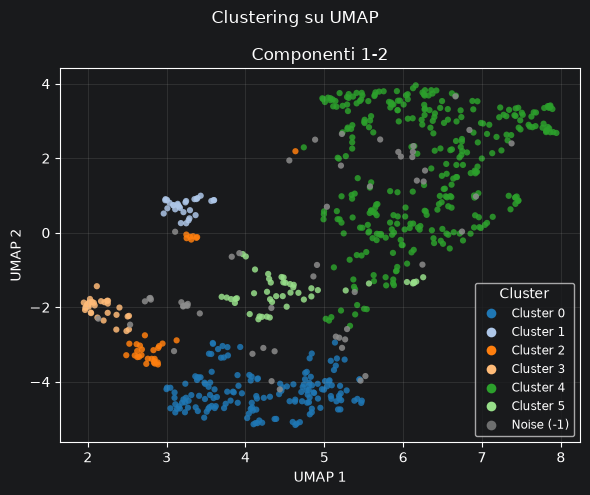

(<Figure size 600x500 with 1 Axes>,
 (<Axes: title={'center': 'Componenti 1-2'}, xlabel='UMAP 1', ylabel='UMAP 2'>,))

In [7]:
plot_clustering_on_umap(
    pca_95_embedding,
    labels,
    n_neighbors=n_neighbors,
)

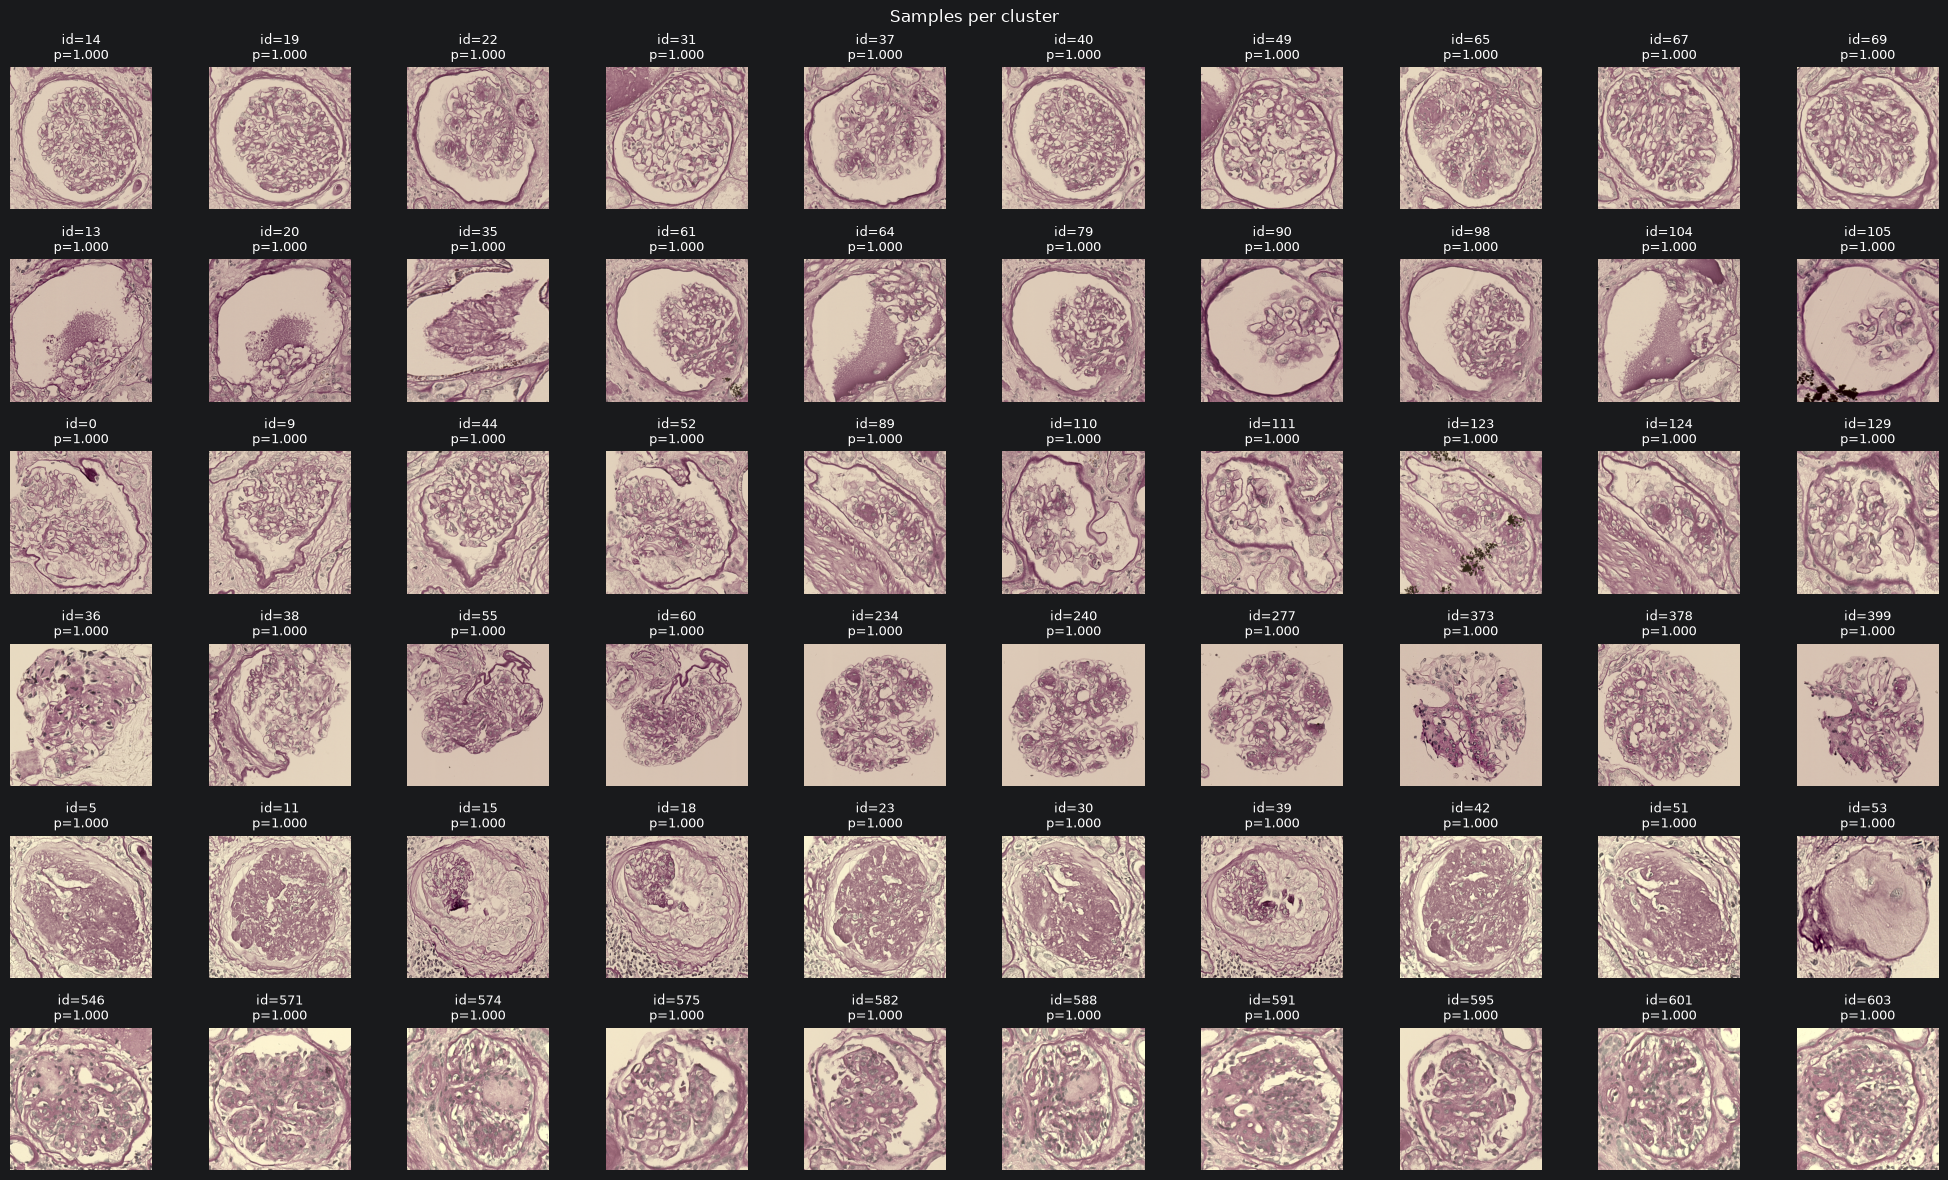

In [8]:
image_paths = csv["image_path"].tolist()

sample_figure, sample_axes = show_clustering_samples(
    labels=labels,
    probabilities=clusterer.probabilities_,
    image_paths=image_paths,
    x=10,
    base_dir=PROJECT_ROOT,
    image_size=2.0,
)

In [9]:
cols = [
    "n_components",
    "successful_runs",
    "valid_runs",
    "valid_run_ratio",
    "mean_dbcv",
    "mean_ari",
    "mean_dbcv_all",
    "mean_ari_all",
    "mean_n_clusters_all",
    "mean_noise_ratio_all",
    "valid_for_selection",
]

print(best["results"][cols].sort_values("n_components"))

print(
    best["run_details"]
    .groupby(["n_components", "constraint_reason"])
    .size()
    .unstack(fill_value=0)
)

   n_components  successful_runs  valid_runs  valid_run_ratio  mean_dbcv  \
2            10               20          14             0.70   0.320803   
4            15               20           8             0.40   0.300691   
5            20               20          11             0.55   0.346042   
3            30               20          13             0.65   0.416292   
1            40               20          15             0.75   0.368385   
0            50               20          16             0.80   0.430800   

   mean_ari  mean_dbcv_all  mean_ari_all  mean_n_clusters_all  \
2  0.732158       0.323555      0.540856                 6.35   
4  0.885243       0.314384      0.693670                 4.60   
5  0.646459       0.329270      0.580574                 5.40   
3  0.806655       0.389416      0.668149                 5.65   
1  0.782760       0.390554      0.673435                 5.25   
0  0.926187       0.415981      0.775616                 5.30   

   mean_noi